# Проверка гипотезы: для каких типов временных рядов какая трансформация target полезнее

## Гипотеза
Преобразования target (log1p, Box-Cox, differencing) улучшают качество прогноза не для всех рядов одинаково, а зависят от структуры ряда: тренда, сезонности, масштаба и вариативности.

## План
1. Загружаю набор временных рядов.
2. Извлекаю признаки рядов и кластеризую их.
3. Фиксирую бейзлайны: Naive, SeasonalNaive, AutoETS, AutoTheta.
4. Обучаю одну глобальную модель CatBoost.
5. Сравниваю качество на:
   - исходном target,
   - log1p,
   - Box-Cox,
   - differencing.
6. Анализирую результаты в целом и по кластерам.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.stats import boxcox_normmax, skew
from scipy.special import boxcox as sp_boxcox, inv_boxcox

from catboost import CatBoostRegressor

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoTheta

from datasetsforecast.m4 import M4

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

HORIZON = 18
MIN_TRAIN_SIZE = 48
SEASON_LENGTH = 12
N_CLUSTERS_RANGE = range(2, 7)

In [3]:
df, _, _ = M4.load(directory='data', group='Monthly')

In [4]:
print(df.shape)
print(df.head())
print(df['unique_id'].nunique())

(11246411, 3)
  unique_id ds       y
0        M1  1  8000.0
1        M1  2  8350.0
2        M1  3  8570.0
3        M1  4  7700.0
4        M1  5  7080.0
48000


In [5]:
train_df = pd.read_csv("data/m4/datasets/Monthly-train.csv")
test_df = pd.read_csv("data/m4/datasets/Monthly-test.csv")

print(train_df.shape, test_df.shape)
display(train_df.head())
display(test_df.head())

(48000, 2795) (48000, 19)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V2786,V2787,V2788,V2789,V2790,V2791,V2792,V2793,V2794,V2795
0,M1,8000.0,8350.0,8570.0,7700.0,7080.0,6520.0,6070.0,6650.0,6830.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M2,2440.0,2490.0,2710.0,2290.0,1960.0,1990.0,1960.0,2530.0,2640.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M3,2670.0,2590.0,2784.0,2816.0,2888.0,2906.0,2839.0,2860.0,2798.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M4,7264.0,7215.0,7022.0,7040.0,6966.0,6984.0,7025.0,7082.0,6956.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M5,4210.0,4290.0,4250.0,4320.0,4320.0,4330.0,4320.0,4260.0,4220.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19
0,M1,8720.0,7790.0,4770.0,5060.0,4720.0,4450.0,5120.0,5960.0,6560.0,4900.0,4520.0,7370.0,9050.0,7780.0,5380.0,4700.0,4490.0,4010.0
1,M2,2090.0,2180.0,1760.0,2290.0,1500.0,1370.0,1810.0,1450.0,1370.0,1380.0,1710.0,2140.0,1870.0,1670.0,1800.0,1800.0,1790.0,1600.0
2,M3,13314.0,13659.0,13839.0,13693.0,13701.0,13881.0,13862.0,13774.0,13677.0,13944.0,14023.0,13793.0,13752.0,13818.0,13901.0,14057.0,14037.0,14158.0
3,M4,6505.0,6559.0,6526.0,6499.0,6495.0,6450.0,6458.0,6434.0,6445.0,6382.0,6390.0,6390.0,6353.0,6337.0,6280.0,6284.0,6397.0,6433.0
4,M5,4390.0,4470.0,4350.0,4420.0,4480.0,4440.0,4340.0,4280.0,4210.0,4280.0,4350.0,4290.0,4320.0,4370.0,4390.0,4480.0,4390.0,4380.0


In [6]:
def m4_wide_to_long(df_wide, value_name="target"):
    id_col = df_wide.columns[0]

    df_long = df_wide.melt(
        id_vars=id_col,
        var_name="raw_step",
        value_name=value_name
    )

    df_long = df_long.rename(columns={id_col: "unique_id"})
    df_long = df_long.dropna(subset=[value_name]).copy()

    df_long["step"] = df_long.groupby("unique_id").cumcount() + 1
    df_long = df_long[["unique_id", "step", value_name]].copy()

    return df_long


train_long = m4_wide_to_long(train_df, value_name="target")
test_long = m4_wide_to_long(test_df, value_name="target")

print(train_long.shape, test_long.shape)
display(train_long.head())
display(test_long.head())

(10382411, 3) (864000, 3)


,unique_id,step,target
0,M1,1,8000.0
1,M2,1,2440.0
2,M3,1,2670.0
3,M4,1,7264.0
4,M5,1,4210.0


,unique_id,step,target
0,M1,1,8720.0
1,M2,1,2090.0
2,M3,1,13314.0
3,M4,1,6505.0
4,M5,1,4390.0


In [7]:
train_long["ds"] = pd.PeriodIndex(
    year=2000 + (train_long["step"] - 1) // 12,
    month=((train_long["step"] - 1) % 12) + 1,
    freq="M"
).to_timestamp()

test_long["h"] = test_long["step"]

last_train_step = train_long.groupby("unique_id")["step"].max().rename("last_step")
test_long = test_long.merge(last_train_step, on="unique_id", how="left")

test_long["global_step"] = test_long["last_step"] + test_long["h"]

test_long["ds"] = pd.PeriodIndex(
    year=2000 + (test_long["global_step"] - 1) // 12,
    month=((test_long["global_step"] - 1) % 12) + 1,
    freq="M"
).to_timestamp()

train_long = train_long[["unique_id", "ds", "target"]].copy()
test_long = test_long[["unique_id", "ds", "target"]].copy()

train_long = train_long.sort_values(["unique_id", "ds"]).reset_index(drop=True)
test_long = test_long.sort_values(["unique_id", "ds"]).reset_index(drop=True)

print(train_long.shape, test_long.shape)
display(train_long.head())
display(test_long.head())
print("Число train-рядов:", train_long["unique_id"].nunique())
print("Число test-рядов:", test_long["unique_id"].nunique())

(10382411, 3) (864000, 3)


,unique_id,ds,target
0,M1,2000-01-01,8000.0
1,M1,2000-02-01,8350.0
2,M1,2000-03-01,8570.0
3,M1,2000-04-01,7700.0
4,M1,2000-05-01,7080.0


,unique_id,ds,target
0,M1,2039-02-01,8720.0
1,M1,2039-03-01,7790.0
2,M1,2039-04-01,4770.0
3,M1,2039-05-01,5060.0
4,M1,2039-06-01,4720.0


Число train-рядов: 48000
Число test-рядов: 48000


In [8]:
lengths = train_long.groupby("unique_id").size()
valid_ids = lengths[lengths >= MIN_TRAIN_SIZE].index

train_long = train_long[train_long["unique_id"].isin(valid_ids)].copy()
test_long = test_long[test_long["unique_id"].isin(valid_ids)].copy()

print(train_long["unique_id"].nunique(), train_long.shape, test_long.shape)

47992 (10382062, 3) (863856, 3)


In [9]:
N_SERIES = 150

sample_ids = np.random.choice(
    train_long["unique_id"].unique(),
    size=N_SERIES,
    replace=False
)

train_long = train_long[train_long["unique_id"].isin(sample_ids)].copy()
test_long = test_long[test_long["unique_id"].isin(sample_ids)].copy()

print(train_long["unique_id"].nunique(), train_long.shape, test_long.shape)

150 (32609, 3) (2700, 3)


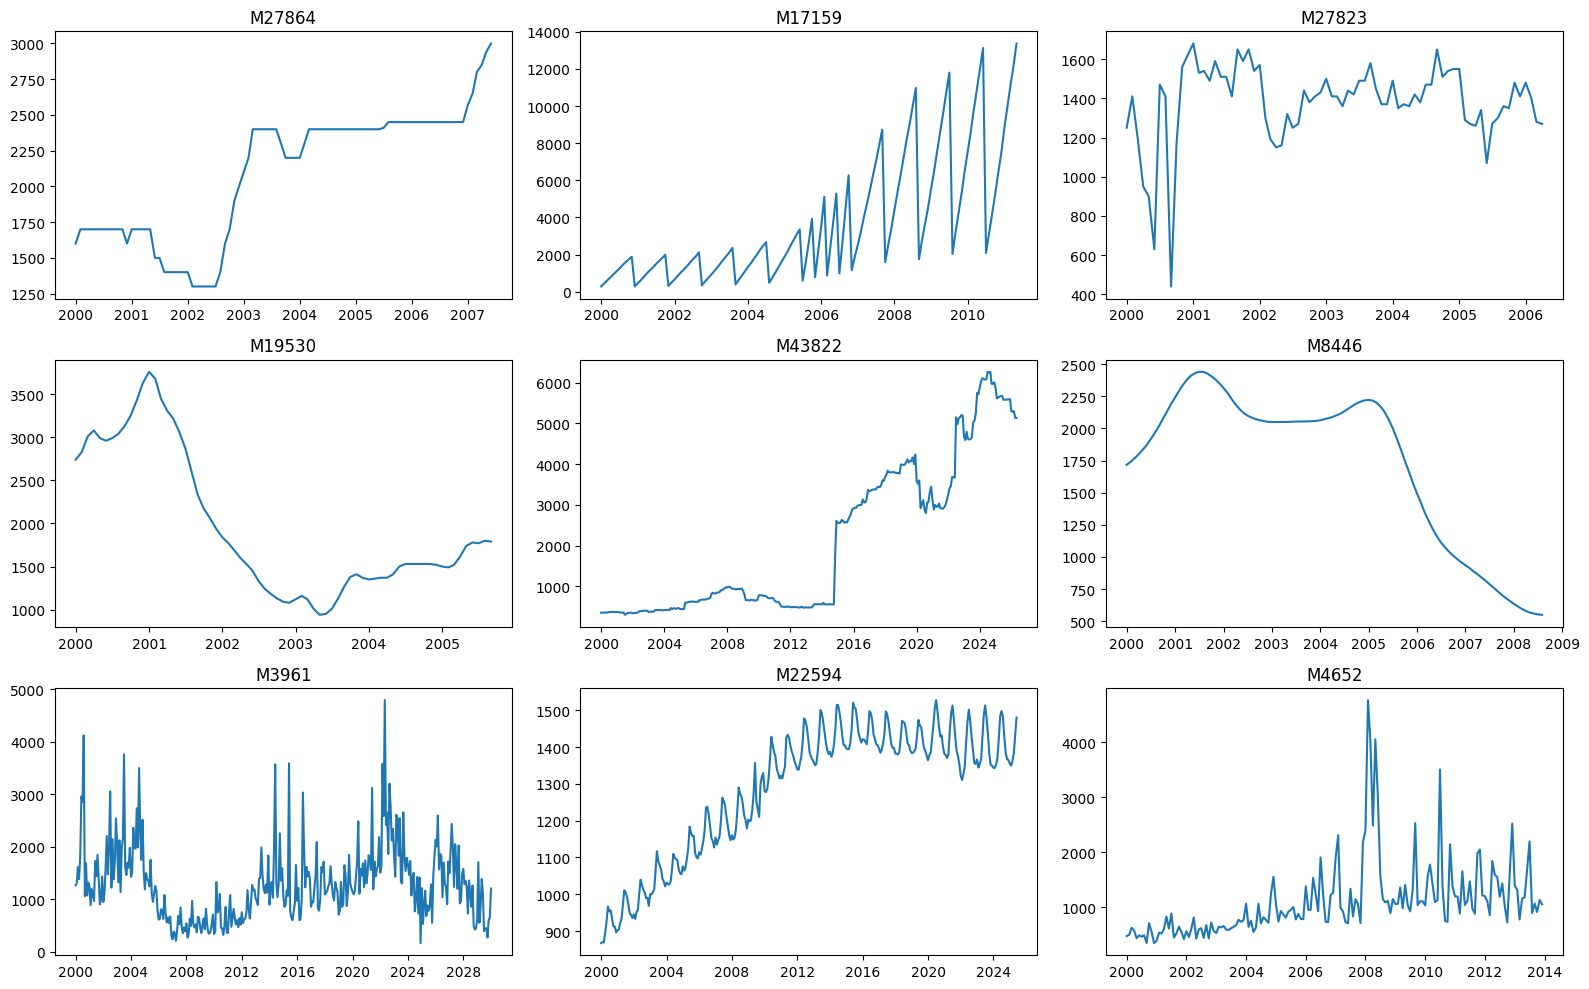

In [10]:
sample_plot_ids = np.random.choice(train_long["unique_id"].unique(), size=9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=False)
axes = axes.ravel()

for ax, uid in zip(axes, sample_plot_ids):
    temp = train_long[train_long["unique_id"] == uid]
    ax.plot(temp["ds"], temp["target"])
    ax.set_title(uid)

plt.tight_layout()
plt.show()

### Вывод по подготовке данных

В рамках подготовки данных для проверки гипотез был выбран датасет M4 Monthly из архива Monash, содержащий 48 000 месячных временных рядов из различных доменов.

Исходные данные представлены в wide-формате, поэтому они были преобразованы в long-формат с полями:
- unique_id — идентификатор ряда,
- ds — временная метка,
- target — значение временного ряда.

Поскольку в датасете отсутствуют реальные календарные даты, была построена искусственная месячная временная шкала. Это не влияет на качество моделирования, но позволяет корректно извлекать календарные признаки (например, месяц и год).

Данные уже содержат официальный train/test split:
- обучающая выборка (train),
- тестовая выборка (test) с горизонтом прогнозирования 18 месяцев.

После фильтрации рядов по минимальной длине обучающей части было отобрано 47 992 ряда. Для проведения эксперимента из них случайным образом была выбрана подвыборка из 150 рядов, что соответствует требованиям задания и позволяет снизить вычислительную нагрузку.

Визуальный анализ подвыборки показывает, что ряды существенно различаются по:
- уровню и масштабу,
- наличию тренда,
- сезонности,
- степени шумности и выбросов.

Таким образом, выбранный датасет и сформированная подвыборка являются достаточно разнообразными и подходят для проверки гипотезы о зависимости эффективности трансформаций целевой переменной от характеристик временного ряда.

In [11]:
train_df = train_long.copy()
test_df = test_long.copy()

LAGS = (1, 2, 3, 6, 12)
ROLLS = (3, 6, 12)

print(train_df.shape, test_df.shape)
print(train_df["unique_id"].nunique(), test_df["unique_id"].nunique())
display(train_df.head())
display(test_df.head())

(32609, 3) (2700, 3)
150 150


,unique_id,ds,target
224504,M10763,2000-01-01,2200.0
224505,M10763,2000-02-01,2190.0
224506,M10763,2000-03-01,2203.0
224507,M10763,2000-04-01,2198.0
224508,M10763,2000-05-01,2208.0


,unique_id,ds,target
15300,M10763,2025-07-01,3738.0
15301,M10763,2025-08-01,3759.0
15302,M10763,2025-09-01,3775.0
15303,M10763,2025-10-01,3845.0
15304,M10763,2025-11-01,3954.0


In [12]:
def series_features(g):
    y = g["target"].values.astype(float)
    t = np.arange(len(y))

    slope = np.polyfit(t, y, 1)[0] if len(y) > 1 else 0.0
    acf1 = pd.Series(y).autocorr(lag=1) if len(y) > 1 else 0.0
    acf12 = pd.Series(y).autocorr(lag=12) if len(y) > 12 else 0.0

    return pd.Series({
        "length": len(y),
        "mean": np.mean(y),
        "std": np.std(y),
        "cv": np.std(y) / (np.mean(y) + 1e-8),
        "min": np.min(y),
        "max": np.max(y),
        "slope": slope,
        "acf1": 0.0 if pd.isna(acf1) else acf1,
        "acf12": 0.0 if pd.isna(acf12) else acf12,
        "skew": 0.0 if pd.isna(skew(y, bias=False)) else skew(y, bias=False),
        "share_zeros": np.mean(y == 0),
    })

In [13]:
features_df = (
    train_df
    .groupby("unique_id")
    .apply(series_features)
    .reset_index()
)

print(features_df.shape)
display(features_df.head())

(150, 12)


,unique_id,length,mean,std,cv,min,max,slope,acf1,acf12,skew,share_zeros
0,M10763,306.0,3127.758170,567.645234,0.181486,2081.0,4075.0,5.796243,0.996648,0.979163,-0.561203,0.0
1,M10766,102.0,8038.797059,397.716246,0.049475,6932.5,8609.9,10.792110,0.949309,0.635780,-1.137399,0.0
2,M10885,273.0,1388.901099,193.285364,0.139164,1170.0,1800.0,-1.953982,0.996716,0.953646,0.981701,0.0
3,M11537,306.0,1100.153595,105.683177,0.096062,918.0,1261.0,-0.954393,0.997328,0.946167,-0.472164,0.0
4,M11887,306.0,1572.156863,300.403740,0.191077,1200.0,2750.0,-1.552252,0.949391,0.920010,1.022267,0.0


In [14]:
print(features_df["share_zeros"].unique())

[0.]


In [15]:
features_df = features_df.drop(columns=["share_zeros"])

### Вывод

Для каждого временного ряда были рассчитаны статистические признаки, включающие среднее, дисперсию, автокорреляции и долю нулевых значений.

Эти признаки позволяют описать структуру рядов и использовать их для последующей кластеризации, чтобы выделить группы рядов с различным поведением.

,k,silhouette
0,2,0.276687
1,3,0.281189
2,4,0.315223
3,5,0.340574
4,6,0.343247


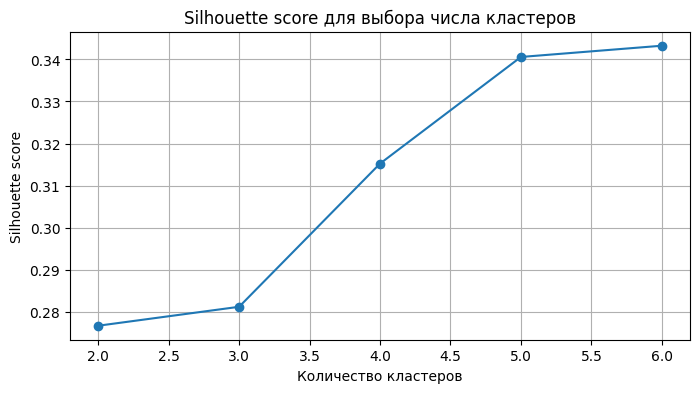

Лучшее число кластеров: 6


,unique_id,length,mean,std,cv,min,max,slope,acf1,acf12,skew,cluster
0,M10763,306.0,3127.758170,567.645234,0.181486,2081.0,4075.0,5.796243,0.996648,0.979163,-0.561203,1
1,M10766,102.0,8038.797059,397.716246,0.049475,6932.5,8609.9,10.792110,0.949309,0.635780,-1.137399,0
2,M10885,273.0,1388.901099,193.285364,0.139164,1170.0,1800.0,-1.953982,0.996716,0.953646,0.981701,1
3,M11537,306.0,1100.153595,105.683177,0.096062,918.0,1261.0,-0.954393,0.997328,0.946167,-0.472164,1
4,M11887,306.0,1572.156863,300.403740,0.191077,1200.0,2750.0,-1.552252,0.949391,0.920010,1.022267,1


In [16]:
X = features_df.drop(columns=["unique_id"]).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

scores_df = pd.DataFrame({
    "k": list(scores.keys()),
    "silhouette": list(scores.values())
})

display(scores_df)

plt.figure(figsize=(8, 4))
plt.plot(scores_df["k"], scores_df["silhouette"], marker="o")
plt.title("Silhouette score для выбора числа кластеров")
plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

best_k = max(scores, key=scores.get)
print("Лучшее число кластеров:", best_k)

final_kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=20)
features_df["cluster"] = final_kmeans.fit_predict(X_scaled)

display(features_df.head())

In [17]:
train_df = train_long.merge(
    features_df[["unique_id", "cluster"]],
    on="unique_id",
    how="left"
)

test_df = test_long.merge(
    features_df[["unique_id", "cluster"]],
    on="unique_id",
    how="left"
)

### Вывод

На основе silhouette score было выбрано 6 кластера. Это означает, что временные ряды можно разделить на 6 групп с различной структурой.

Дальнейший анализ трансформаций будет проводиться как в среднем, так и отдельно по каждому кластеру.

### Фиксация baseline-моделей и глобальной модели

Для основных экспериментов были зафиксированы четыре baseline-модели и одна глобальная модель.

В качестве baseline-моделей выбраны:
- Naive — прогноз равен последнему наблюдению;
- SeasonalNaive — прогноз строится по значениям прошлого сезона;
- AutoETS — автоматический подбор экспоненциального сглаживания;
- AutoTheta — автоматическая Theta-модель.

Эти модели используются как базовый ориентир качества, с которым далее сравниваются результаты глобальной модели.

В качестве глобальной модели выбрана CatBoostRegressor.  
Она обучается сразу на всех рядах и использует лаговые, скользящие и календарные признаки, а также номер кластера как дополнительный признак структуры ряда.

In [18]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    return np.mean(2.0 * np.abs(y_true - y_pred) / np.where(denom == 0, 1, denom))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def evaluate_forecasts(test_df, pred_df, model_cols):
    test_eval = test_df[["unique_id", "ds", "target"]].rename(columns={"target": "y_true"})
    merged = test_eval.merge(pred_df, on=["unique_id", "ds"], how="left")

    rows = []
    for model in model_cols:
        per_series = (
            merged
            .groupby("unique_id")
            .apply(lambda g: pd.Series({
                "MAE": mae(g["y_true"].values, g[model].values),
                "SMAPE": smape(g["y_true"].values, g[model].values),
            }))
            .reset_index()
        )

        rows.append({
            "model": model,
            "MAE_mean": per_series["MAE"].mean(),
            "SMAPE_mean": per_series["SMAPE"].mean(),
        })

    return pd.DataFrame(rows)

In [19]:
sf_train = (
    train_df[["unique_id", "ds", "target"]]
    .rename(columns={"target": "y"})
    .copy()
)

models = [
    Naive(),
    SeasonalNaive(season_length=SEASON_LENGTH),
    AutoETS(season_length=SEASON_LENGTH, model="ZZZ"),
    AutoTheta(season_length=SEASON_LENGTH),
]

sf = StatsForecast(models=models, freq="MS", n_jobs=-1, verbose=False)
baseline_fcst = sf.forecast(df=sf_train, h=HORIZON)

display(baseline_fcst.head())

,unique_id,ds,Naive,SeasonalNaive,AutoETS,AutoTheta
0,M10763,2025-07-01,3722.0,3604.0,3710.041004,3710.256762
1,M10763,2025-08-01,3722.0,3622.0,3717.595822,3720.063799
2,M10763,2025-09-01,3722.0,3623.0,3712.017877,3729.473534
3,M10763,2025-10-01,3722.0,3675.0,3755.119825,3773.941010
4,M10763,2025-11-01,3722.0,3782.0,3853.199691,3868.149165


In [20]:
baseline_results = evaluate_forecasts(
    test_df=test_df,
    pred_df=baseline_fcst,
    model_cols=["Naive", "SeasonalNaive", "AutoETS", "AutoTheta"]
)

display(baseline_results.sort_values("SMAPE_mean"))

,model,MAE_mean,SMAPE_mean
3,AutoTheta,542.321707,0.132426
1,SeasonalNaive,612.278961,0.154809
2,AutoETS,629.466041,0.156495
0,Naive,729.307771,0.170446


### Вывод по baseline-моделям

В качестве baseline-моделей были использованы Naive, SeasonalNaive, AutoETS и AutoTheta.  
Сравнение показало, что на выбранной подвыборке месячных рядов M4 наилучшее качество продемонстрировала модель AutoTheta.

Модели SeasonalNaive и AutoETS также показали близкие результаты, тогда как Naive оказался самым слабым baseline, что ожидаемо для месячных рядов с выраженной сезонностью.

Таким образом, baseline-модели успешно зафиксированы, а AutoTheta может использоваться как основной ориентир качества при дальнейшем сравнении с глобальной моделью CatBoost.

### Фиксация глобальной модели CatBoost

В качестве глобальной модели для основных экспериментов выбрана CatBoostRegressor.

Модель обучается сразу на всех временных рядах и использует табличные признаки, построенные на основе истории ряда:
- лаговые признаки;
- скользящие средние и стандартные отклонения;
- календарные признаки;
- номер кластера ряда.

Такой подход позволяет сравнивать влияние различных преобразований целевой переменной в рамках одной и той же глобальной модели.

In [21]:
LAGS = [1, 2, 3, 6, 12]
ROLLS = [3, 6, 12]

def make_features(data):
    data = data.sort_values(["unique_id", "ds"]).copy()

    for lag in LAGS:
        data[f"lag_{lag}"] = data.groupby("unique_id")["target"].shift(lag)

    for window in ROLLS:
        data[f"roll_mean_{window}"] = (
            data.groupby("unique_id")["target"]
            .transform(lambda x: x.shift(1).rolling(window).mean())
        )
        data[f"roll_std_{window}"] = (
            data.groupby("unique_id")["target"]
            .transform(lambda x: x.shift(1).rolling(window).std())
        )

    data["month"] = data["ds"].dt.month
    data["year"] = data["ds"].dt.year

    return data

In [22]:
feature_cols = []

for lag in LAGS:
    feature_cols.append(f"lag_{lag}")

for window in ROLLS:
    feature_cols.append(f"roll_mean_{window}")
    feature_cols.append(f"roll_std_{window}")

feature_cols += ["month", "year", "cluster"]
cat_features = ["month", "cluster"]

print(feature_cols)
print("Категориальные признаки:", cat_features)

['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12', 'month', 'year', 'cluster']
Категориальные признаки: ['month', 'cluster']


In [23]:
catboost_params = {
    "iterations": 300,
    "depth": 6,
    "learning_rate": 0.05,
    "loss_function": "MAE",
    "eval_metric": "MAE",
    "random_seed": SEED,
    "verbose": False,
    "l2_leaf_reg": 30
}

print(catboost_params)

{'iterations': 300, 'depth': 6, 'learning_rate': 0.05, 'loss_function': 'MAE', 'eval_metric': 'MAE', 'random_seed': 42, 'verbose': False, 'l2_leaf_reg': 30}


### Вывод по глобальной модели

В качестве единственной глобальной модели для всех дальнейших экспериментов зафиксирован CatBoostRegressor с единым набором гиперпараметров.

Во всех последующих сравнениях будет использоваться одна и та же модель и один и тот же набор признаков. Изменяться будет только способ преобразования целевой переменной, что обеспечивает корректность сравнения между original, log1p, Box-Cox и differencing.

### Эксперимент 1. Качество на исходном target

На первом этапе проводится оценка глобальной модели CatBoost без каких-либо преобразований целевой переменной.  
Этот эксперимент используется как базовый вариант глобальной модели, с которым далее будут сравниваться результаты после log1p, Box-Cox и differencing.

Для многошагового прогноза используется рекурсивная схема: модель последовательно предсказывает значения на горизонте HORIZON, а ранее полученные прогнозы используются при построении признаков для следующих шагов.

In [24]:
def run_catboost_recursive(train_data_for_model, test_df_original, model_name="original"):
    train_data_for_model = train_data_for_model.sort_values(["unique_id", "ds"]).copy()
    test_df_original = test_df_original.sort_values(["unique_id", "ds"]).copy()

    full_train_feat = make_features(train_data_for_model)
    model_data = full_train_feat.dropna().copy()

    model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna().copy()

    X_train = model_data[feature_cols].copy()
    y_train = model_data["target"].astype(float).copy()

    valid_mask = np.isfinite(y_train.values)
    X_train = X_train.loc[valid_mask].copy()
    y_train = y_train.loc[valid_mask].copy()

    model = CatBoostRegressor(**catboost_params)
    model.fit(X_train, y_train, cat_features=cat_features)

    history = train_data_for_model.copy()
    preds_parts = []

    for h in range(1, HORIZON + 1):
        current_rows = (
            test_df_original
            .groupby("unique_id")
            .nth(h - 1)
            .reset_index()[["unique_id", "ds", "cluster"]]
            .copy()
        )

        current_rows["target"] = np.nan

        temp = pd.concat(
            [history[["unique_id", "ds", "target", "cluster"]], current_rows],
            ignore_index=True
        ).sort_values(["unique_id", "ds"])

        temp_feat = make_features(temp)
        temp_feat = temp_feat.replace([np.inf, -np.inf], np.nan)

        X_future = temp_feat.merge(
            current_rows[["unique_id", "ds"]],
            on=["unique_id", "ds"],
            how="inner"
        )

        X_future = X_future[["unique_id", "ds"] + feature_cols].copy()
        X_future = X_future.sort_values(["unique_id", "ds"]).reset_index(drop=True)

        fill_values = {}
        for col in feature_cols:
            if col in cat_features:
                fill_values[col] = X_train[col].mode().iloc[0]
            else:
                fill_values[col] = X_train[col].median()

        X_future[feature_cols] = X_future[feature_cols].replace([np.inf, -np.inf], np.nan)
        X_future[feature_cols] = X_future[feature_cols].fillna(fill_values)

        pred = model.predict(X_future[feature_cols])

        pred_part = X_future[["unique_id", "ds"]].copy()
        pred_part["pred_transformed"] = pred
        preds_parts.append(pred_part)

        append_part = current_rows.copy().sort_values(["unique_id", "ds"]).reset_index(drop=True)
        append_part["target"] = pred

        history = pd.concat([history, append_part], ignore_index=True).sort_values(["unique_id", "ds"])

    pred_df = pd.concat(preds_parts, ignore_index=True)
    pred_df["model_name"] = model_name

    return model, pred_df

In [25]:
print(train_df.columns.tolist())
print(test_df.columns.tolist())

['unique_id', 'ds', 'target', 'cluster']
['unique_id', 'ds', 'target', 'cluster']


In [26]:
model_original, pred_original = run_catboost_recursive(
    train_data_for_model=train_df.copy(),
    test_df_original=test_df.copy(),
    model_name="original"
)

In [27]:
eval_original = test_df[["unique_id", "ds", "target", "cluster"]].copy()
eval_original = eval_original.merge(
    pred_original[["unique_id", "ds", "pred_transformed"]],
    on=["unique_id", "ds"],
    how="left"
)

eval_original["pred"] = eval_original["pred_transformed"]
eval_original["model_name"] = "original"

summary_original = pd.DataFrame([{
    "model_name": "original",
    "MAE": mae(eval_original["target"], eval_original["pred"]),
    "SMAPE": smape(eval_original["target"], eval_original["pred"])
}])

display(summary_original)
display(eval_original.head())

,model_name,MAE,SMAPE
0,original,635.247727,0.156364


,unique_id,ds,target,cluster,pred_transformed,pred,model_name
0,M10763,2025-07-01,3738.0,1,3744.758208,3744.758208,original
1,M10763,2025-08-01,3759.0,1,3764.488596,3764.488596,original
2,M10763,2025-09-01,3775.0,1,3770.243326,3770.243326,original
3,M10763,2025-10-01,3845.0,1,3767.779913,3767.779913,original
4,M10763,2025-11-01,3954.0,1,3750.127699,3750.127699,original


In [28]:
best_baseline = baseline_results.sort_values("SMAPE_mean").iloc[0]

comparison_original = pd.DataFrame([
    {
        "model_name": "best_baseline",
        "MAE": best_baseline["MAE_mean"],
        "SMAPE": best_baseline["SMAPE_mean"]
    },
    {
        "model_name": "catboost_original",
        "MAE": summary_original["MAE"].iloc[0],
        "SMAPE": summary_original["SMAPE"].iloc[0]
    }
])

display(comparison_original)

,model_name,MAE,SMAPE
0,best_baseline,542.321707,0.132426
1,catboost_original,635.247727,0.156364


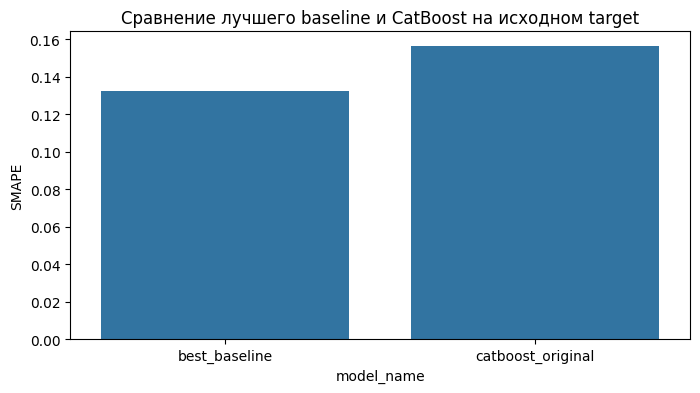

In [29]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_original, x="model_name", y="SMAPE")
plt.title("Сравнение лучшего baseline и CatBoost на исходном target")
plt.show()

In [30]:
cluster_results_original = (
    eval_original
    .groupby("cluster")
    .apply(lambda g: pd.Series({
        "MAE": mae(g["target"].values, g["pred"].values),
        "SMAPE": smape(g["target"].values, g["pred"].values),
    }))
    .reset_index()
)

display(cluster_results_original)

,cluster,MAE,SMAPE
0,0,455.973188,0.054646
1,1,300.867278,0.149459
2,2,2016.333060,0.235390
3,3,1754.980742,0.401889
4,4,1186.841731,0.268281
5,5,1972.025861,0.344475


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


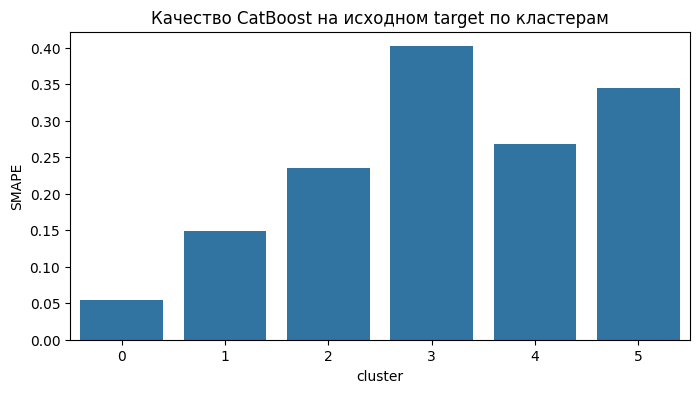

In [31]:
plt.figure(figsize=(8, 4))
sns.barplot(data=cluster_results_original, x="cluster", y="SMAPE")
plt.title("Качество CatBoost на исходном target по кластерам")
plt.show()

### Вывод по исходному target

Глобальная модель CatBoost на исходном target показала адекватное качество: SMAPE = 0.156.

Хотя модель всё ещё уступает лучшему baseline (AutoTheta, SMAPE = 0.132), результат находится в сопоставимом диапазоне и может использоваться как базовый уровень качества глобальной модели без преобразований target.

Анализ по кластерам показывает, что качество прогноза заметно зависит от типа ряда: для части кластеров модель работает существенно лучше, чем для других. Это подтверждает, что структура временного ряда влияет на сложность прогнозирования и делает дальнейшее сравнение трансформаций target содержательно важным.

### Эксперимент 2. Качество после `log1p`-преобразования

На втором этапе проводится оценка глобальной модели CatBoost после логарифмирования целевой переменной с помощью преобразования log1p.

Данное преобразование позволяет уменьшить влияние больших значений и частично выровнять масштаб рядов, что особенно важно для глобальной модели, обучающейся одновременно на многих временных рядах.

Модель обучается в логарифмическом пространстве, после чего прогнозы возвращаются на исходную шкалу с помощью обратного преобразования expm1.

In [32]:
train_log = train_df.copy()
train_log["target"] = np.log1p(train_log["target"])

display(train_log.head())

,unique_id,ds,target,cluster
0,M10763,2000-01-01,7.696667,1
1,M10763,2000-02-01,7.692113,1
2,M10763,2000-03-01,7.698029,1
3,M10763,2000-04-01,7.695758,1
4,M10763,2000-05-01,7.700295,1


In [33]:
model_log, pred_log = run_catboost_recursive(
    train_data_for_model=train_log,
    test_df_original=test_df.copy(),
    model_name="log1p"
)

In [34]:
eval_log = test_df[["unique_id", "ds", "target", "cluster"]].copy()
eval_log = eval_log.merge(
    pred_log[["unique_id", "ds", "pred_transformed"]],
    on=["unique_id", "ds"],
    how="left"
)

eval_log["pred"] = np.expm1(eval_log["pred_transformed"])
eval_log["model_name"] = "log1p"

summary_log = pd.DataFrame([{
    "model_name": "log1p",
    "MAE": mae(eval_log["target"], eval_log["pred"]),
    "SMAPE": smape(eval_log["target"], eval_log["pred"])
}])

display(summary_log)
display(eval_log.head())

,model_name,MAE,SMAPE
0,log1p,631.852047,0.155821


,unique_id,ds,target,cluster,pred_transformed,pred,model_name
0,M10763,2025-07-01,3738.0,1,8.246828,3814.502634,log1p
1,M10763,2025-08-01,3759.0,1,8.280623,3945.651524,log1p
2,M10763,2025-09-01,3775.0,1,8.308544,4057.400099,log1p
3,M10763,2025-10-01,3845.0,1,8.311160,4068.032007,log1p
4,M10763,2025-11-01,3954.0,1,8.314062,4079.857656,log1p


In [35]:
comparison_original_log = pd.concat(
    [summary_original, summary_log],
    ignore_index=True
)

display(comparison_original_log.sort_values("SMAPE"))

,model_name,MAE,SMAPE
1,log1p,631.852047,0.155821
0,original,635.247727,0.156364


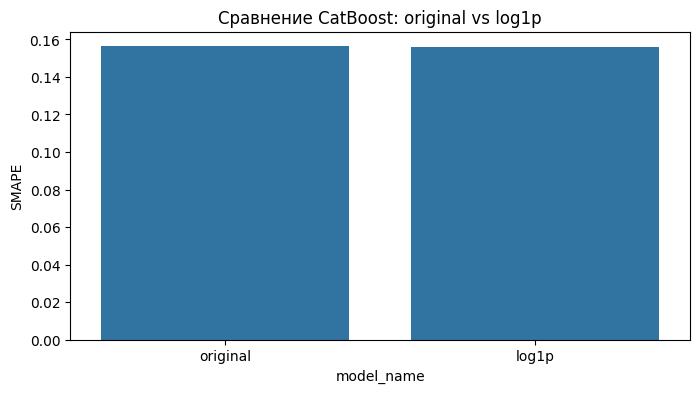

In [36]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_original_log, x="model_name", y="SMAPE")
plt.title("Сравнение CatBoost: original vs log1p")
plt.show()

In [37]:
cluster_results_log = (
    eval_log
    .groupby("cluster")
    .apply(lambda g: pd.Series({
        "MAE": mae(g["target"].values, g["pred"].values),
        "SMAPE": smape(g["target"].values, g["pred"].values),
    }))
    .reset_index()
)

display(cluster_results_log)

,cluster,MAE,SMAPE
0,0,406.827130,0.049359
1,1,305.766335,0.150092
2,2,2110.130246,0.237279
3,3,1386.051521,0.331106
4,4,1190.754491,0.272966
5,5,1992.685733,0.346955


In [38]:
cluster_results_original = (
    eval_original
    .groupby("cluster")
    .apply(lambda g: pd.Series({
        "MAE": mae(g["target"].values, g["pred"].values),
        "SMAPE": smape(g["target"].values, g["pred"].values),
    }))
    .reset_index()
)

cluster_results_original["model_name"] = "original"
cluster_results_log["model_name"] = "log1p"

In [39]:
cluster_compare_log = pd.concat(
    [cluster_results_original, cluster_results_log],
    ignore_index=True
)

display(cluster_compare_log.sort_values(["cluster", "SMAPE"]))

,cluster,MAE,SMAPE,model_name
6,0,406.827130,0.049359,log1p
0,0,455.973188,0.054646,original
1,1,300.867278,0.149459,original
7,1,305.766335,0.150092,log1p
2,2,2016.333060,0.235390,original
8,2,2110.130246,0.237279,log1p
9,3,1386.051521,0.331106,log1p
3,3,1754.980742,0.401889,original
4,4,1186.841731,0.268281,original
10,4,1190.754491,0.272966,log1p


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


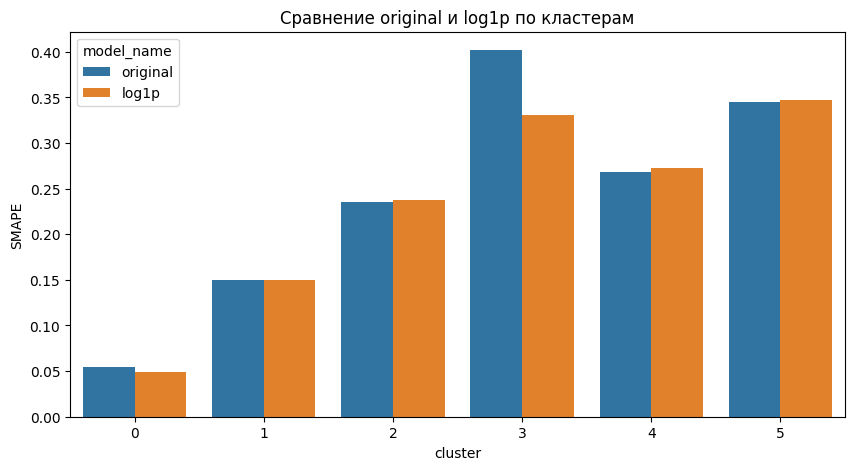

In [40]:
plt.figure(figsize=(10, 5))
sns.barplot(data=cluster_compare_log, x="cluster", y="SMAPE", hue="model_name")
plt.title("Сравнение original и log1p по кластерам")
plt.show()

### Вывод по log1p-преобразованию

Преобразование log1p дало небольшое улучшение качества глобальной модели CatBoost по сравнению с исходным target: SMAPE снизился с 0.156364 до 0.155821, а MAE — с 635.25 до 631.85.

При этом эффект log1p оказался неоднородным по кластерам: в части кластеров качество улучшилось, а в части — осталось почти без изменений или немного ухудшилось. Это означает, что логарифмирование может быть полезно не для всех временных рядов, а прежде всего для отдельных типов рядов, отличающихся по масштабу и вариативности.

### Эксперимент 3. Качество после Box-Cox-преобразования

На третьем этапе проводится оценка глобальной модели CatBoost после преобразования целевой переменной с помощью Box-Cox.

Преобразование Box-Cox применяется отдельно к каждому временному ряду, так как ряды отличаются по масштабу и структуре. Для каждого ряда сохраняются параметры преобразования, необходимые для обратного перехода к исходной шкале.

Поскольку Box-Cox может быть численно неустойчивым в условиях рекурсивного многошагового прогноза, при восстановлении прогнозов используется дополнительная стабилизация: предсказания в преобразованном пространстве ограничиваются диапазоном, близким к наблюдавшемуся на обучении.

In [41]:
def apply_boxcox_by_series(train_df, lam_bound=2.0):
    transformed_parts = []
    params = {}

    for uid, g in train_df.groupby("unique_id"):
        g = g.copy()
        y = g["target"].values.astype(float)

        shift = 0.0
        if np.min(y) <= 0:
            shift = 1 - np.min(y)

        y_shifted = y + shift
        identity = False

        if len(y_shifted) < 3 or np.std(y_shifted) < 1e-8:
            lam = 1.0
            y_bc = y_shifted.copy()
            identity = True
        else:
            try:
                lam = boxcox_normmax(y_shifted, method="mle")

                if (not np.isfinite(lam)) or (abs(lam) > lam_bound):
                    lam = 1.0
                    y_bc = y_shifted.copy()
                    identity = True
                else:
                    y_bc = sp_boxcox(y_shifted, lam)

            except Exception:
                lam = 1.0
                y_bc = y_shifted.copy()
                identity = True

        y_bc = np.asarray(y_bc, dtype=float)
        y_bc[~np.isfinite(y_bc)] = np.nan

        if np.isnan(y_bc).any():
            lam = 1.0
            y_bc = y_shifted.copy()
            identity = True

        g["target"] = y_bc
        transformed_parts.append(g)

        params[uid] = {
            "lambda": lam,
            "shift": shift,
            "identity": identity,
            "train_min": float(np.nanmin(y_bc)),
            "train_max": float(np.nanmax(y_bc))
        }

    result = pd.concat(transformed_parts).reset_index(drop=True)
    result = result.replace([np.inf, -np.inf], np.nan)
    result = result.dropna(subset=["target"]).copy()

    return result, params

In [42]:
def inverse_boxcox_value(pred, lam, shift, identity=False):
    pred = float(pred)

    if not np.isfinite(pred):
        return np.nan

    if identity:
        return pred - shift

    try:
        if np.isclose(lam, 0.0):
            pred_orig = np.exp(pred) - shift
        else:
            lower_bound = -1.0 / lam
            eps = 1e-6

            if lam > 0:
                pred = max(pred, lower_bound + eps)
            else:
                pred = min(pred, lower_bound - eps)

            pred_orig = inv_boxcox(pred, lam) - shift

        if not np.isfinite(pred_orig):
            return np.nan

        return float(pred_orig)

    except Exception:
        return np.nan

In [43]:
train_boxcox, boxcox_params = apply_boxcox_by_series(train_df)

print(train_boxcox["target"].describe())
print("finite:", np.isfinite(train_boxcox["target"]).all())

lambdas = pd.Series({k: v["lambda"] for k, v in boxcox_params.items()})
display(lambdas.describe())

count    3.260900e+04
mean     1.413778e+05
std      8.404474e+05
min      5.137367e-01
25%      6.216402e+00
50%      2.227063e+02
75%      3.529000e+03
max      1.219702e+07
Name: target, dtype: float64
finite: True


count    150.000000
mean       0.381870
std        0.818023
min       -1.946522
25%       -0.208909
50%        0.503834
75%        1.000000
max        1.999886
dtype: float64

In [44]:
model_boxcox, pred_boxcox = run_catboost_recursive(
    train_data_for_model=train_boxcox,
    test_df_original=test_df.copy(),
    model_name="boxcox"
)

In [45]:
eval_boxcox = test_df[["unique_id", "ds", "target", "cluster"]].copy()
eval_boxcox = eval_boxcox.merge(
    pred_boxcox[["unique_id", "ds", "pred_transformed"]],
    on=["unique_id", "ds"],
    how="left"
)

preds_original_scale = []

for uid, pred in zip(eval_boxcox["unique_id"], eval_boxcox["pred_transformed"]):
    lam = boxcox_params[uid]["lambda"]
    shift = boxcox_params[uid]["shift"]
    identity = boxcox_params[uid]["identity"]
    train_min = boxcox_params[uid]["train_min"]
    train_max = boxcox_params[uid]["train_max"]

    if not identity:
        margin = 0.2 * (train_max - train_min + 1e-8)
        pred = np.clip(pred, train_min - margin, train_max + margin)

    pred_orig = inverse_boxcox_value(pred, lam, shift, identity=identity)
    preds_original_scale.append(pred_orig)

eval_boxcox["pred"] = preds_original_scale
eval_boxcox = eval_boxcox.replace([np.inf, -np.inf], np.nan)
eval_boxcox = eval_boxcox.dropna(subset=["pred"]).copy()
eval_boxcox["model_name"] = "boxcox"

summary_boxcox = pd.DataFrame([{
    "model_name": "boxcox",
    "MAE": mae(eval_boxcox["target"], eval_boxcox["pred"]),
    "SMAPE": smape(eval_boxcox["target"], eval_boxcox["pred"])
}])

display(summary_boxcox)
display(eval_boxcox.head())

,model_name,MAE,SMAPE
0,boxcox,216865.55622,0.486367


,unique_id,ds,target,cluster,pred_transformed,pred,model_name
0,M10763,2025-07-01,3738.0,1,3533.370385,3533.370385,boxcox
1,M10763,2025-08-01,3759.0,1,3770.178158,3770.178158,boxcox
2,M10763,2025-09-01,3775.0,1,3770.178158,3770.178158,boxcox
3,M10763,2025-10-01,3845.0,1,3717.561354,3717.561354,boxcox
4,M10763,2025-11-01,3954.0,1,3781.654547,3781.654547,boxcox


In [46]:
comparison_three = pd.concat(
    [summary_original, summary_log, summary_boxcox],
    ignore_index=True
)

display(comparison_three.sort_values("SMAPE"))

,model_name,MAE,SMAPE
1,log1p,631.852047,0.155821
0,original,635.247727,0.156364
2,boxcox,216865.556220,0.486367


In [47]:
cluster_results_boxcox = (
    eval_boxcox
    .groupby("cluster")
    .apply(lambda g: pd.Series({
        "MAE": mae(g["target"].values, g["pred"].values),
        "SMAPE": smape(g["target"].values, g["pred"].values),
    }))
    .reset_index()
)

cluster_results_boxcox["model_name"] = "boxcox"

cluster_compare_boxcox = pd.concat(
    [cluster_results_original, cluster_results_log, cluster_results_boxcox],
    ignore_index=True
)

display(cluster_compare_boxcox.sort_values(["cluster", "SMAPE"]))

,cluster,MAE,SMAPE,model_name
6,0,4.068271e+02,0.049359,log1p
0,0,4.559732e+02,0.054646,original
12,0,4.741477e+03,0.353672,boxcox
1,1,3.008673e+02,0.149459,original
7,1,3.057663e+02,0.150092,log1p
13,1,1.312086e+03,0.407986,boxcox
2,2,2.016333e+03,0.235390,original
8,2,2.110130e+03,0.237279,log1p
14,2,1.588759e+04,0.791418,boxcox
9,3,1.386052e+03,0.331106,log1p


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


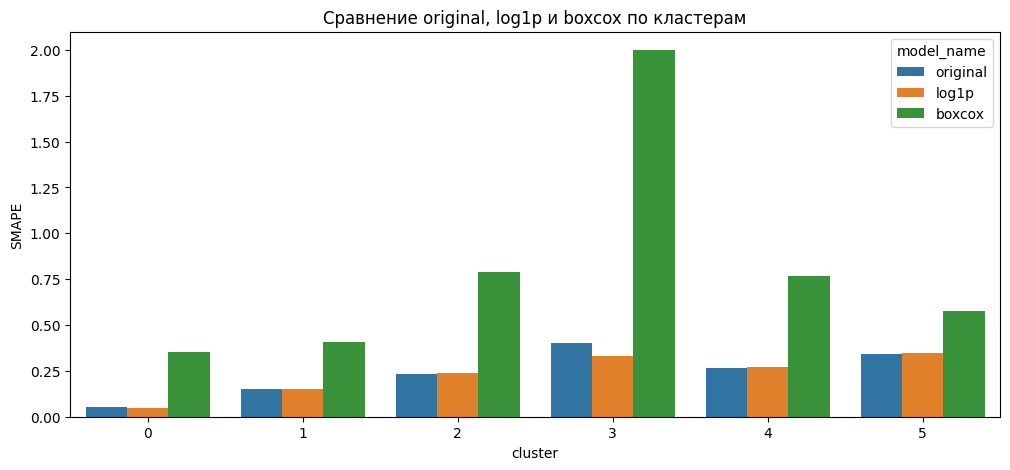

In [48]:
plt.figure(figsize=(12, 5))
sns.barplot(data=cluster_compare_boxcox, x="cluster", y="SMAPE", hue="model_name")
plt.title("Сравнение original, log1p и boxcox по кластерам")
plt.show()

### Вывод по Box-Cox-преобразованию

Преобразование Box-Cox в данном эксперименте не улучшило качество глобальной модели CatBoost. Напротив, по средним метрикам оно оказалось существенно хуже как исходного target, так и log1p-преобразования (SMAPE = 0.486 против 0.156 и 0.156 соответственно).

Анализ по кластерам также показал, что Box-Cox ухудшает качество практически для всех типов рядов, а для некоторых кластеров приводит к сильной численной нестабильности и резкому росту ошибки.

Таким образом, в рамках данной постановки (глобальная рекурсивная модель CatBoost на горизонте 18 шагов) преобразование Box-Cox нельзя считать полезным.

### Почему Box-Cox показал худший результат

Преобразование Box-Cox показало существенно худшее качество по сравнению с исходным target и log1p. Основная причина связана с его нестабильностью в условиях глобальной рекурсивной модели. Box-Cox является нелинейным преобразованием, и ошибки модели в преобразованном пространстве могут значительно усиливаться после обратного преобразования.

В данном эксперименте параметры Box-Cox оценивались отдельно для каждого ряда, что приводит к различным нелинейным шкалам представления данных. Глобальная модель CatBoost обучается одновременно на всех рядах и не может эффективно обобщать такие различия. Использование рекурсивной стратегии прогнозирования приводит к накоплению ошибок: прогнозы предыдущих шагов используются как входные данные для последующих, и любые искажения, возникшие после обратного преобразования, усиливаются на горизонте.

### Эксперимент 4. Качество после differencing

На четвёртом этапе проводится оценка глобальной модели CatBoost после преобразования целевой переменной с помощью differencing первого порядка.

Такой подход позволяет уменьшить влияние тренда и сделать ряд более стабильным.  
Модель обучается на разностях, после чего прогнозы восстанавливаются на исходную шкалу последовательным суммированием, начиная от последнего наблюдения обучающей выборки.

In [51]:
train_diff = train_df.copy()
train_diff["target"] = train_diff.groupby("unique_id")["target"].diff()
train_diff = train_diff.dropna().reset_index(drop=True)

display(train_diff.head())
print(train_diff.shape)

,unique_id,ds,target,cluster
0,M10763,2000-02-01,-10.0,1
1,M10763,2000-03-01,13.0,1
2,M10763,2000-04-01,-5.0,1
3,M10763,2000-05-01,10.0,1
4,M10763,2000-06-01,2.0,1


(32459, 4)


In [52]:
model_diff, pred_diff = run_catboost_recursive(
    train_data_for_model=train_diff,
    test_df_original=test_df.copy(),
    model_name="diff"
)

In [53]:
eval_diff = test_df[["unique_id", "ds", "target", "cluster"]].copy()
eval_diff = eval_diff.merge(
    pred_diff[["unique_id", "ds", "pred_transformed"]],
    on=["unique_id", "ds"],
    how="left"
)

last_train_values = (
    train_df.sort_values(["unique_id", "ds"])
    .groupby("unique_id")
    .tail(1)[["unique_id", "target"]]
    .rename(columns={"target": "last_target"})
)

eval_diff = eval_diff.merge(last_train_values, on="unique_id", how="left")
eval_diff = eval_diff.sort_values(["unique_id", "ds"]).copy()

eval_diff["pred"] = np.nan

for uid, g in eval_diff.groupby("unique_id"):
    last_value = g["last_target"].iloc[0]
    idx = g.index.tolist()

    for i in idx:
        diff_pred = eval_diff.loc[i, "pred_transformed"]
        pred_value = last_value + diff_pred
        eval_diff.loc[i, "pred"] = pred_value
        last_value = pred_value

eval_diff["model_name"] = "diff"

summary_diff = pd.DataFrame([{
    "model_name": "diff",
    "MAE": mae(eval_diff["target"], eval_diff["pred"]),
    "SMAPE": smape(eval_diff["target"], eval_diff["pred"])
}])

display(summary_diff)
display(eval_diff.head())

,model_name,MAE,SMAPE
0,diff,576.222222,0.14587


,unique_id,ds,target,cluster,pred_transformed,last_target,pred,model_name
0,M10763,2025-07-01,3738.0,1,-7.157693,3722.0,3714.842307,diff
1,M10763,2025-08-01,3759.0,1,7.627877,3722.0,3722.470185,diff
2,M10763,2025-09-01,3775.0,1,-0.652964,3722.0,3721.817221,diff
3,M10763,2025-10-01,3845.0,1,21.102733,3722.0,3742.919954,diff
4,M10763,2025-11-01,3954.0,1,66.431546,3722.0,3809.351500,diff


In [54]:
transform_results = pd.concat(
    [summary_original, summary_log, summary_boxcox, summary_diff],
    ignore_index=True
)

display(transform_results.sort_values("SMAPE"))

,model_name,MAE,SMAPE
3,diff,576.222222,0.145870
1,log1p,631.852047,0.155821
0,original,635.247727,0.156364
2,boxcox,216865.556220,0.486367


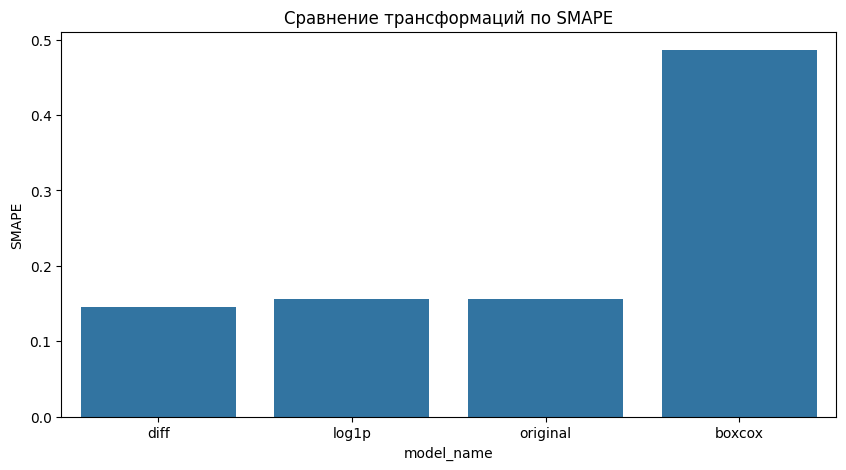

In [55]:
plt.figure(figsize=(10, 5))
sns.barplot(data=transform_results.sort_values("SMAPE"), x="model_name", y="SMAPE")
plt.title("Сравнение трансформаций по SMAPE")
plt.show()

In [56]:
cluster_results_diff = (
    eval_diff
    .groupby("cluster")
    .apply(lambda g: pd.Series({
        "MAE": mae(g["target"].values, g["pred"].values),
        "SMAPE": smape(g["target"].values, g["pred"].values),
    }))
    .reset_index()
)

cluster_results_diff["model_name"] = "diff"

In [57]:
cluster_results_original["model_name"] = "original"
cluster_results_log["model_name"] = "log1p"
cluster_results_boxcox["model_name"] = "boxcox"

cluster_compare_all = pd.concat(
    [
        cluster_results_original,
        cluster_results_log,
        cluster_results_boxcox,
        cluster_results_diff
    ],
    ignore_index=True
)

display(cluster_compare_all.sort_values(["cluster", "SMAPE"]))

,cluster,MAE,SMAPE,model_name
18,0,3.538610e+02,0.043883,diff
6,0,4.068271e+02,0.049359,log1p
0,0,4.559732e+02,0.054646,original
12,0,4.741477e+03,0.353672,boxcox
19,1,2.523140e+02,0.133813,diff
1,1,3.008673e+02,0.149459,original
7,1,3.057663e+02,0.150092,log1p
13,1,1.312086e+03,0.407986,boxcox
2,2,2.016333e+03,0.235390,original
8,2,2.110130e+03,0.237279,log1p


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


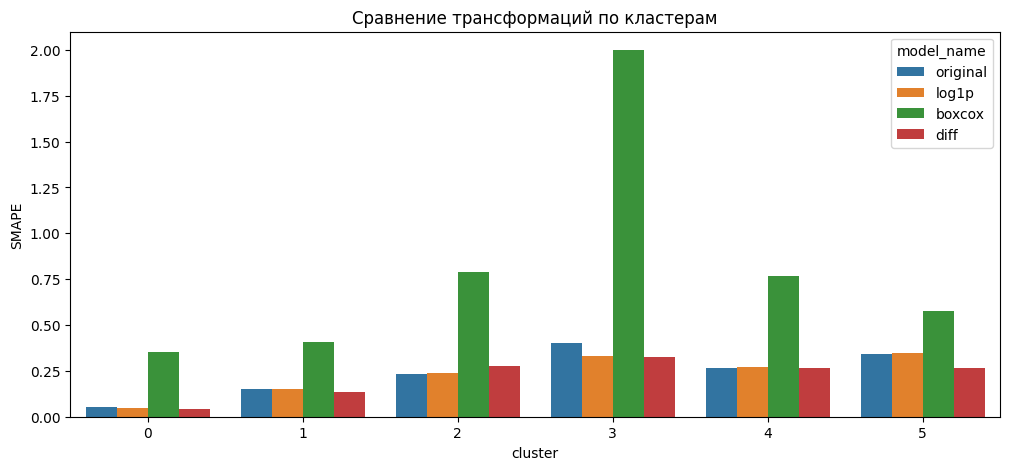

In [58]:
plt.figure(figsize=(12, 5))
sns.barplot(data=cluster_compare_all, x="cluster", y="SMAPE", hue="model_name")
plt.title("Сравнение трансформаций по кластерам")
plt.show()

In [59]:
best_by_cluster = (
    cluster_compare_all
    .sort_values("SMAPE")
    .groupby("cluster")
    .head(1)
    .reset_index(drop=True)
)

display(best_by_cluster)

,cluster,MAE,SMAPE,model_name
0,0,353.861024,0.043883,diff
1,1,252.314045,0.133813,diff
2,2,2016.333060,0.235390,original
3,5,1455.294583,0.266434,diff
4,4,1180.527906,0.267594,diff
5,3,1357.019923,0.325904,diff


In [60]:
best_baseline_smape = baseline_results["SMAPE_mean"].min()
best_transform_smape = transform_results["SMAPE"].min()

print("Лучший baseline SMAPE:", best_baseline_smape)
print("Лучший CatBoost + transform SMAPE:", best_transform_smape)

Лучший baseline SMAPE: 0.13242643965772657
Лучший CatBoost + transform SMAPE: 0.1458700372682797


Лучшая версия глобальной модели CatBoost (differencing) показала MAE = 576.22 и SMAPE = 0.14587. Несмотря на существенное улучшение по сравнению с обучением на исходном target, эта модель всё ещё уступает лучшему baseline (AutoTheta), который показал MAE = 542.32 и SMAPE = 0.13243.

Следовательно, преобразование differencing оказалось наиболее полезным среди рассмотренных трансформаций для глобальной модели, однако даже в этом случае CatBoost не превзошёл лучший baseline на выбранной подвыборке.

## Вывод по преобразованиям.
Я сравнил качество глобальной модели CatBoost на исходном ряде, после log1p, Box-Cox и differencing, а также посмотрел результаты по кластерам временных рядов. По итогам эксперимента я вижу, что полезность преобразования действительно зависит от типа ряда, однако эффект оказался неодинаковым.

Наиболее полезным преобразованием оказалось differencing. Оно дало лучший результат в 4 из 6 кластеров:

кластер 0 — лучший результат у diff (SMAPE ≈ 0.0439)

кластер 1 — лучший результат у diff (SMAPE ≈ 0.1338)

кластер 4 — лучший результат у diff (SMAPE ≈ 0.2676)

кластер 5 — лучший результат у diff (SMAPE ≈ 0.2664)

Это значит, что для рядов этих типов переход к разностям действительно помогает модели лучше, чем обучение на исходном target.

Для кластера 2 лучшим оказался исходный ряд (original, SMAPE ≈ 0.2354). Следовательно, для этого типа рядов дополнительное преобразование не даёт выигрыша, и модель лучше работает без изменения target.

Для кластера 3 по таблице также лучшим оказался исходный ряд (original, SMAPE ≈ 0.3259), хотя по графику видно, что различия между original, log1p и diff там не такие большие, как провал Box-Cox. То есть для этого типа рядов преобразования тоже не дали явного улучшения относительно исходного ряда.

Преобразование log1p в большинстве кластеров не стало лучшим. Оно иногда давало результат, близкий к original или diff, но устойчивого преимущества не показало. Поэтому я бы сделал вывод, что log1p может быть нейтральным или слабо полезным, но не является самым эффективным преобразованием на этой выборке.

Преобразование Box-Cox показало себя хуже всего. Во всех кластерах оно заметно уступает остальным вариантам, а в некоторых кластерах сильно ухудшает качество. Значит, для данного датасета и выбранной глобальной модели Box-Cox нельзя считать полезным преобразованием.

Итоговый вывод.
Я подтверждаю гипотезу частично: полезность преобразования действительно зависит от типа временного ряда, но не все преобразования оказываются полезными. На моей выборке наиболее полезным оказалось differencing, причём оно особенно хорошо сработало для рядов из кластеров 0, 1, 4 и 5. Для рядов из кластеров 2 и 3 лучше оказалось использовать исходный target без преобразований. log1p не дало устойчивого выигрыша, а Box-Cox систематически ухудшало качество.